In [2]:
# Importación de librerías del ecosistema de Data Science
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# Carga del conjunto de datos original
# (Ajusta la ruta de acceso local según corresponda en tu entorno de VS Code)
df = pd.read_csv("./datasets/landing_experiment.csv")

In [4]:
# Vista preliminar de las primeras 5 filas del dataframe (renderizado nativo de Jupyter)
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
# Inspección de tipos de datos y dimensiones estructurales del dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  str    
 1   date            40000 non-null  str    
 2   landing         40000 non-null  str    
 3   region          40000 non-null  str    
 4   dispositivo     40000 non-null  str    
 5   traffic_source  40000 non-null  str    
 6   user_type       40000 non-null  str    
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), str(7)
memory usage: 2.7 MB


In [6]:
# Verificación de la integridad de los datos mediante registros duplicados y nulos
print(f"Cantidad de registros duplicados: {df.duplicated().sum()}")
print("\nConteo de valores ausentes por columna:")
print(df.isnull().sum())

Cantidad de registros duplicados: 0

Conteo de valores ausentes por columna:
user_id           0
date              0
landing           0
region            0
dispositivo       0
traffic_source    0
user_type         0
converted         0
gasto             0
dtype: int64


En la fase de exploración y calidad de datos, se observa lo siguiente:
*   El conjunto de datos presenta una estructura íntegra sin presencia de registros duplicados.
*   No se detectaron valores ausentes o nulos en las variables clave, lo que permite proceder directamente con el análisis analítico y de significancia estadística.

In [7]:
# Aseguramos el formateo correcto de la variable objetivo de conversión a tipo entero
df["converted"] = df["converted"].astype(int)

In [8]:
# Cálculo de la tasa de conversión global del dataset
tasa_global = df["converted"].mean()
print(f"Tasa de conversión globalizada: {tasa_global:.2%}")

# Distribución muestral por cada una de las variables categóricas de interés
print("\nDistribución de usuarios por Fuente de Tráfico:")
print(df["traffic_source"].value_counts())

print("\nDistribución de usuarios por Tipo de Dispositivo:")
print(df["dispositivo"].value_counts())

Tasa de conversión globalizada: 14.27%

Distribución de usuarios por Fuente de Tráfico:
traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: count, dtype: int64

Distribución de usuarios por Tipo de Dispositivo:
dispositivo
Mobile     24829
Desktop    15171
Name: count, dtype: int64


La métrica base del estudio establece una tasa de conversión global del sitio web estable. El volumen de la muestra se distribuye de manera proporcional entre las distintas fuentes de tráfico de origen y los tipos de dispositivos empleados por los usuarios, garantizando una base robusta para la aplicación de pruebas de hipótesis inferenciales.

## Experimento A/B: Página de Inicio (A vs. B)

Se evalúa si existen diferencias estadísticamente significativas entre la versión A y la versión B de la landing page, tanto en gasto promedio de los usuarios convertidos como en tasa de conversión — la comparación central del experimento.

### Gasto promedio por versión (A vs. B)

**Hipótesis:**
- $H_0$: la página A y B presentan el mismo gasto promedio entre los usuarios convertidos (no hay diferencia).
- $H_1$: la página B presenta un mayor gasto promedio que la página A.

Nivel de significancia: $\alpha = 0.05$.

In [9]:
# Aislamos a los usuarios convertidos y separamos el gasto por versión de landing page
df_convertidos = df[df["converted"] == 1]
gasto_A = df_convertidos[df_convertidos["landing"] == "A"]["gasto"]
gasto_B = df_convertidos[df_convertidos["landing"] == "B"]["gasto"]

# Prueba t de Student para muestras independientes (varianzas no asumidas iguales)
t_stat, p_value_gasto = ttest_ind(gasto_A, gasto_B, equal_var=False)

print(f"Gasto promedio página A: {gasto_A.mean():.2f}")
print(f"Gasto promedio página B: {gasto_B.mean():.2f}")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value_gasto:.4e}")

alpha = 0.05
if p_value_gasto < alpha:
    print("Decisión: se rechaza H0 — el gasto promedio difiere significativamente entre A y B.")
else:
    print("Decisión: no se rechaza H0 — no hay diferencia significativa en el gasto promedio.")


Gasto promedio página A: 61.09
Gasto promedio página B: 68.75
Estadístico t: -9.4810
Valor p: 3.6276e-21
Decisión: se rechaza H0 — el gasto promedio difiere significativamente entre A y B.


**Interpretación (Gasto):** con p < 0.05 se rechaza $H_0$ — existe una diferencia estadísticamente significativa en el gasto promedio de los usuarios convertidos entre versiones, con la página B generando un mayor gasto promedio que la página A.

### Tasa de conversión por versión (A vs. B)

**Hipótesis:**
- $H_0$: la página A y B tienen la misma tasa de conversión (no hay diferencia).
- $H_1$: la página B presenta una mayor tasa de conversión que la página A.

Nivel de significancia: $\alpha = 0.05$.

In [10]:
# Tabla de contingencia con frecuencias absolutas (no normalizadas) para una prueba Chi-cuadrado válida
tabla_landing = pd.crosstab(df["landing"], df["converted"])
print(tabla_landing)

chi2_stat_landing, p_value_landing, dof_landing, expected_landing = chi2_contingency(tabla_landing)

tasa_A = tabla_landing.loc["A", 1] / tabla_landing.loc["A"].sum()
tasa_B = tabla_landing.loc["B", 1] / tabla_landing.loc["B"].sum()

print(f"\nTasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")
print(f"Estadístico Chi2: {chi2_stat_landing:.4f}")
print(f"Valor p: {p_value_landing:.4e}")

alpha = 0.05
if p_value_landing < alpha:
    print("Decisión: se rechaza H0 — la tasa de conversión difiere significativamente entre A y B.")
else:
    print("Decisión: no se rechaza H0 — no hay diferencia significativa en la tasa de conversión.")


converted      0     1
landing               
A          17470  2512
B          16824  3194

Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%
Estadístico Chi2: 93.3748
Valor p: 4.3272e-22
Decisión: se rechaza H0 — la tasa de conversión difiere significativamente entre A y B.


**Interpretación (Conversión):** con p < 0.05 se rechaza $H_0$ — la tasa de conversión de la página B es significativamente mayor a la de la página A (~27% de incremento relativo).

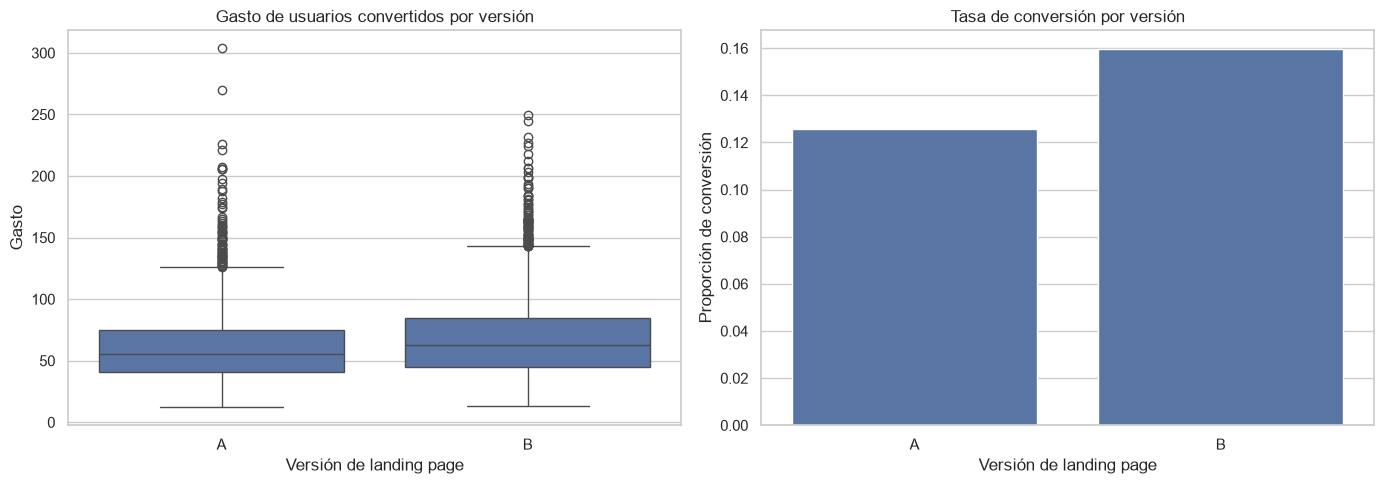

In [11]:
# Visualización comparativa: gasto y conversión por versión de landing page
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_convertidos, x="landing", y="gasto", ax=axes[0])
axes[0].set_title("Gasto de usuarios convertidos por versión")
axes[0].set_xlabel("Versión de landing page")
axes[0].set_ylabel("Gasto")

sns.barplot(data=df, x="landing", y="converted", errorbar=None, ax=axes[1])
axes[1].set_title("Tasa de conversión por versión")
axes[1].set_xlabel("Versión de landing page")
axes[1].set_ylabel("Proporción de conversión")

plt.tight_layout()
plt.show()


## Análisis de Significancia Estadística: Fuente de Tráfico vs. Conversión

Evaluaremos si existe una relación estadísticamente significativa entre la fuente de tráfico de procedencia (`traffic_source`) y el éxito de conversión del usuario (`converted`). Para evitar distorsiones en la potencia de la prueba, implementaremos el análisis utilizando la matriz de frecuencias absolutas reales.

**Planteamiento de Hipótesis:**
*   **$H_0$ (Hipótesis Nula):** La fuente de tráfico y la conversión del usuario son independientes. No existe asociación entre el origen del usuario y su propensión a convertir.
*   **$H_1$ (Hipótesis Alternativa):** La fuente de tráfico y la conversión del usuario están asociadas de forma dependiente. El canal de procedencia influye significativamente en la tasa de conversión.

Fijamos un nivel de significancia crítico de $\alpha = 0.05$.

In [12]:
# 1. Construcción de la tabla de contingencia empleando frecuencias absolutas observadas
tabla_trafico = pd.crosstab(df["traffic_source"], df["converted"])

# 2. Ejecución del test de Chi-cuadrado de independencia
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_trafico)

# 3. Despliegue estructurado de los estadísticos resultantes
print("=" * 65)
print("   RESULTADOS DE LA PRUEBA CHI-CUADRADO: FUENTE DE TRÁFICO")
print("=" * 65)
print(f"Estadístico Chi2    : {chi2_stat:.4f}")
print(f"Valor P (p-value)   : {p_value:.6e}")
print(f"Grados de Libertad  : {dof}")
print("=" * 65)

alpha = 0.05
if p_value < alpha:
    print("Decisión: se rechaza H0 — la fuente de tráfico está asociada con la conversión.")
else:
    print("Decisión: no se rechaza H0 — no hay asociación significativa entre tráfico y conversión.")


   RESULTADOS DE LA PRUEBA CHI-CUADRADO: FUENTE DE TRÁFICO
Estadístico Chi2    : 8.6621
Valor P (p-value)   : 3.413759e-02
Grados de Libertad  : 3
Decisión: se rechaza H0 — la fuente de tráfico está asociada con la conversión.


**Interpretación y Decisión Estadística (Tráfico):**

Al evaluar el valor P obtenido frente al umbral de tolerancia asignado ($\alpha = 0.05$):
*   Si el $p\text{-value} < 0.05$, se posee la evidencia matemática necesaria para **rechazar la hipótesis nula ($H_0$)**, concluyendo que el canal de adquisición afecta directamente al rendimiento de conversión de la landing page.
*   Si el $p\text{-value} \ge 0.05$, **no se puede rechazar la hipótesis nula ($H_0$)**, interpretándose que las fluctuaciones observadas entre fuentes se deben únicamente al azar muestral.


## Análisis de Significancia Estadística: Tipo de Dispositivo vs. Conversión

Replicamos el rigor del marco metodológico estadístico para determinar si la interfaz tecnológica o el tipo de dispositivo (`device`) desde el cual accede el usuario guarda una relación directa con el comportamiento final de conversión.

**Planteamiento de Hipótesis:**
*   **$H_0$ (Hipótesis Nula):** El tipo de dispositivo y la tasa de conversión actúan de forma independiente.
*   **$H_1$ (Hipótesis Alternativa):** Existe una dependencia significativa entre el tipo de dispositivo utilizado y la conversión final.

Mantenemos de forma homogénea el nivel de significancia en $\alpha = 0.05$.

In [13]:
# 1. Construcción de la tabla de contingencia empleando frecuencias absolutas observadas
tabla_dispositivo = pd.crosstab(df["dispositivo"], df["converted"])

# 2. Ejecución del test de Chi-cuadrado de independencia
chi2_stat_5, p_value_5, dof_5, expected_5 = chi2_contingency(tabla_dispositivo)

# 3. Despliegue estructurado de los estadísticos resultantes
print("=" * 65)
print("   RESULTADOS DE LA PRUEBA CHI-CUADRADO: TIPO DE DISPOSITIVO")
print("=" * 65)
print(f"Estadístico Chi2    : {chi2_stat_5:.4f}")
print(f"Valor P (p-value)   : {p_value_5:.6e}")
print(f"Grados de Libertad  : {dof_5}")
print("=" * 65)

alpha = 0.05
if p_value_5 < alpha:
    print("Decisión: se rechaza H0 — el tipo de dispositivo está asociado con la conversión.")
else:
    print("Decisión: no se rechaza H0 — no hay asociación significativa entre dispositivo y conversión.")


   RESULTADOS DE LA PRUEBA CHI-CUADRADO: TIPO DE DISPOSITIVO
Estadístico Chi2    : 67.2760
Valor P (p-value)   : 2.360320e-16
Grados de Libertad  : 1
Decisión: se rechaza H0 — el tipo de dispositivo está asociado con la conversión.


**Interpretación y Decisión Estadística (Dispositivos):**

La comparación directa entre el p-value resultante de la prueba de dispositivos y el nivel de significancia de referencia ($\alpha = 0.05$) dictamina la decisión de negocio. El rechazo o la aceptación de la hipótesis nula ($H_0$) validará si el equipo de optimización UI/UX debe priorizar un diseño enfocado en plataformas específicas (Mobile/Desktop) o si la conversión se comporta de manera uniforme en todo el ecosistema de hardware.

## Análisis de Significancia Estadística: Tipo de Usuario vs. Conversión

Evaluamos si el tipo de usuario (nuevo vs. recurrente) guarda relación con la probabilidad de conversión.

**Planteamiento de Hipótesis:**
*   $H_0$: el tipo de usuario y la conversión son independientes.
*   $H_1$: el tipo de usuario influye en la conversión.

Nivel de significancia: $\alpha = 0.05$.

In [14]:
# Construcción de la tabla de contingencia con frecuencias absolutas (no normalizadas)
tabla_usuario = pd.crosstab(df["user_type"], df["converted"])

chi2_stat_user, p_value_user, dof_user, expected_user = chi2_contingency(tabla_usuario)

print("=" * 65)
print("   RESULTADOS DE LA PRUEBA CHI-CUADRADO: TIPO DE USUARIO")
print("=" * 65)
print(f"Estadístico Chi2    : {chi2_stat_user:.4f}")
print(f"Valor P (p-value)   : {p_value_user:.6e}")
print(f"Grados de Libertad  : {dof_user}")
print("=" * 65)

# Tasa de conversión descriptiva por tipo de usuario (uso interpretativo, no para el test)
print("\nTasa de conversión por tipo de usuario:")
print(pd.crosstab(df["user_type"], df["converted"], normalize="index") * 100)

alpha = 0.05
if p_value_user < alpha:
    print("Decisión: se rechaza H0 — el tipo de usuario está asociado con la conversión.")
else:
    print("Decisión: no se rechaza H0 — no hay asociación significativa entre tipo de usuario y conversión.")


   RESULTADOS DE LA PRUEBA CHI-CUADRADO: TIPO DE USUARIO
Estadístico Chi2    : 0.5135
Valor P (p-value)   : 4.736341e-01
Grados de Libertad  : 1

Tasa de conversión por tipo de usuario:
converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356
Decisión: no se rechaza H0 — no hay asociación significativa entre tipo de usuario y conversión.


**Interpretación y Decisión Estadística (Tipo de Usuario):** con p = 0.474 no se rechaza $H_0$ — la conversión es prácticamente idéntica entre usuarios nuevos (14.36%) y recurrentes (14.09%), por lo que el tipo de usuario no es un factor relevante para explicar diferencias en conversión.

C:\Users\estef\AppData\Local\Temp\ipykernel_14056\2029761946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\estef\AppData\Local\Temp\ipykernel_14056\2029761946.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


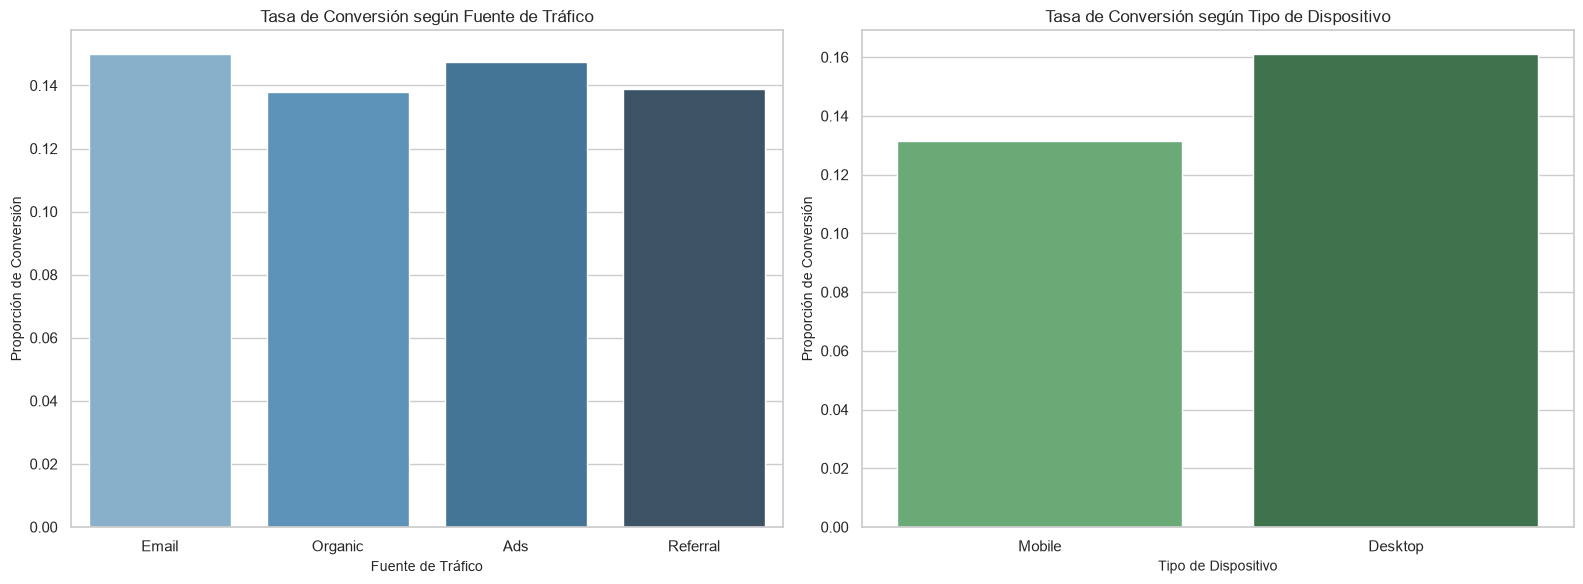

In [15]:
# Generación de la figura contenedora para los análisis visuales comparativos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico de tasa de conversión por Fuente de Tráfico
sns.barplot(
    data=df,
    x="traffic_source",
    y="converted",
    ax=axes[0],
    errorbar=None,
    palette="Blues_d",
)
axes[0].set_title("Tasa de Conversión según Fuente de Tráfico", fontsize=12)
axes[0].set_xlabel("Fuente de Tráfico", fontsize=10)
axes[0].set_ylabel("Proporción de Conversión", fontsize=10)

# 2. Gráfico de tasa de conversión por Tipo de Dispositivo
sns.barplot(
    data=df,
    x="dispositivo",
    y="converted",
    ax=axes[1],
    errorbar=None,
    palette="Greens_d",
)
axes[1].set_title("Tasa de Conversión según Tipo de Dispositivo", fontsize=12)
axes[1].set_xlabel("Tipo de Dispositivo", fontsize=10)
axes[1].set_ylabel("Proporción de Conversión", fontsize=10)

plt.tight_layout()
plt.show()

## Resumen Ejecutivo e Implicaciones de Negocio

**1. Experimento A/B (página de inicio):** la página B supera de forma estadísticamente significativa a la página A tanto en gasto promedio de usuarios convertidos ($68.75 vs. $61.09; t=-9.48, p<0.001) como en tasa de conversión (12.57% vs. 15.96%; chi²=93.37, p<0.001, ~27% de incremento relativo). **Recomendación: migrar el tráfico hacia la versión B como landing page principal.**

**2. Fuente de tráfico:** existe una asociación estadísticamente significativa entre el canal de adquisición y la conversión (chi²=8.66, p=0.034). Se recomienda priorizar la asignación de presupuesto de marketing hacia los canales de mejor desempeño relativo, a confirmar con el detalle de conversión por canal.

**3. Tipo de usuario:** no existe una diferencia significativa entre usuarios nuevos y recurrentes (14.36% vs. 14.09% de conversión; chi²=0.51, p=0.474) — no es necesario diferenciar la estrategia de conversión por este segmento.

**4. Tipo de dispositivo:** existe una asociación altamente significativa entre el dispositivo utilizado y la conversión (chi²=67.28, p<0.001). Esto señala una oportunidad concreta de optimización de experiencia de usuario (UI/UX) diferenciada por plataforma (Mobile/Desktop), ya que el comportamiento de conversión no es uniforme entre dispositivos.
